====== Model Performance Comparison ======
Linear Regression:
MSE: 5.716773957535678
R²: 0.9777557433558923

Ridge Regression:
MSE: 17.87398851290174
R²: 0.9304514065645847

Lasso Regression:
MSE: 6.721527177551376
R²: 0.9738461977527184


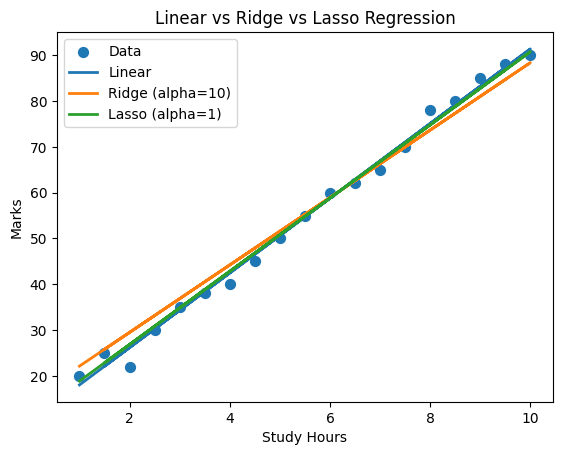

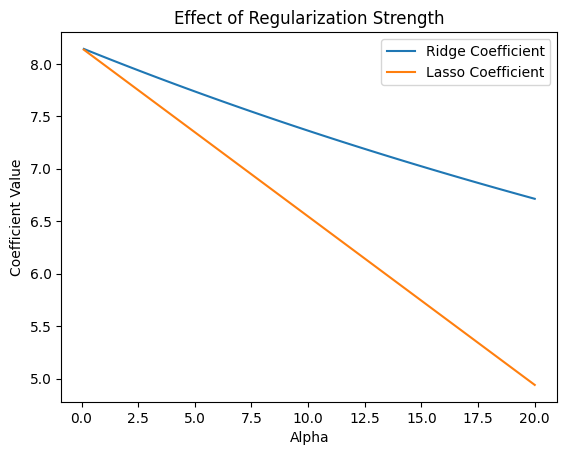

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# -------------------------------
# 1. LOAD DATA
# -------------------------------
data = pd.read_csv("study_marks.csv")
X = data[["Hours"]]
y = data["Marks"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# 2. BASELINE MODEL: LINEAR REGRESSION
# -------------------------------
lin = LinearRegression()
lin.fit(X_train, y_train)

y_pred_lin = lin.predict(X_test)

# -------------------------------
# 3. RIDGE REGRESSION
# -------------------------------
ridge = Ridge(alpha=10)   # alpha controls regularization strength
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# -------------------------------
# 4. LASSO REGRESSION
# -------------------------------
lasso = Lasso(alpha=1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# -------------------------------
# 5. PERFORMANCE COMPARISON
# -------------------------------
print("====== Model Performance Comparison ======")
print("Linear Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("R²:", r2_score(y_test, y_pred_lin))

print("\nRidge Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R²:", r2_score(y_test, y_pred_ridge))

print("\nLasso Regression:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R²:", r2_score(y_test, y_pred_lasso))


# -------------------------------
# 6. PLOTTING RESULTS
# -------------------------------
plt.scatter(X, y, label="Data", s=50)

# plot predictions
plt.plot(X, lin.predict(X), label="Linear", linewidth=2)
plt.plot(X, ridge.predict(X), label="Ridge (alpha=10)", linewidth=2)
plt.plot(X, lasso.predict(X), label="Lasso (alpha=1)", linewidth=2)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear vs Ridge vs Lasso Regression")
plt.legend()
plt.show()


# -------------------------------
# 7. SHOW EFFECT OF REGULARIZATION
# -------------------------------
alphas = np.linspace(0.1, 20, 50)
ridge_coefs = []
lasso_coefs = []

for a in alphas:
    ridge_model = Ridge(alpha=a)
    lasso_model = Lasso(alpha=a)
    ridge_model.fit(X_train, y_train)
    lasso_model.fit(X_train, y_train)
    ridge_coefs.append(ridge_model.coef_[0])
    lasso_coefs.append(lasso_model.coef_[0])

plt.plot(alphas, ridge_coefs, label="Ridge Coefficient")
plt.plot(alphas, lasso_coefs, label="Lasso Coefficient")
plt.xlabel("Alpha")
plt.ylabel("Coefficient Value")
plt.title("Effect of Regularization Strength")
plt.legend()
plt.show()


# New Section